<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/6/68/Logo_FPT_Education.png" width="300" alt="FPT Education logo"  />
</center>

# DAP391M - ARTIFICIAL INTELLIGENCE PROGRAMMING PROJECT


## REPORT 3: MODELING & EVALUATION
**Group name:** [Nhóm 5] | **Class:** [AI2010]
---

## I. Feature Engineering & Selection

### 1.1. Feature Engineering
*Mô tả các bước xử lý dữ liệu để tạo ra các đặc trưng có giá trị cho mô hình.*
- Tạo input đưa vào mô hình
- Đưa giá trị của safety label về 0 (unsafe) và 1 (safe)
- Làm sạch văn bản: xóa kí tự đặc biệt và chuyển về chữ thường 
### 1.2. Feature Selection
*Lựa chọn các đặc trưng quan trọng nhất (Feature Importance).*

In [6]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
translator = str.maketrans('', '', string.punctuation)
df = pd.read_csv("DataForTraining.csv", encoding='utf-8-sig')
df = df.dropna()
df['Original_Safety_Label'] = df['Original_Safety_Label'].apply(lambda x: 1 if x == 'safe' else 0)
df["text"] = (
    "ED_Type: " + df["Eating disorder"].fillna("") +  
    " Prompt_Type: " + df["Prompt Type"].fillna("") +
    " Context: " + df["Context"].fillna("") +
    " Request: " + df["Request"].fillna("") +
    " Response: " + df["Response"].fillna("")
)

df["text"] = df["text"].str.lower()
df["text"] = df["text"].apply(lambda x: x.translate(translator))
df['label'] = df['Original_Safety_Label']
df['text_clean'] = df['text'].apply(lambda x: word_tokenize(x, format="text"))
custom_stopwords = {
    'và', 'nhưng', 'mà', 'thì', 'là', 'rằng', 'vì', 'nên',
    'ở', 'tại', 'trong', 'ngoài', 'đến', 'từ', 'với',
    'này', 'kia', 'đó', 'ấy', 'nào', 'gì', 'sao', 'đâu',
    'những', 'các', 'mọi', 'mỗi', 'từng',
    'ạ', 'nhé', 'nha', 'vâng', 'dạ', 'chứ',
    'đã', 'đang', 'sẽ', 'vừa', 'mới', 'rồi',
    'sau', 'trước', 'khi', 'lúc', 'hãy', 'làm'
}
def remove_stopwords(text):
    words = text.split()
    return " ".join([w for w in words if w.lower() not in custom_stopwords])
df['text_clean'] = df['text_clean'].apply(remove_stopwords)
df = df[['text_clean','label']]
X = df["text_clean"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Sẵn sàng cho giai đoạn chia tập dữ liệu huấn luyện.")

Sẵn sàng cho giai đoạn chia tập dữ liệu huấn luyện.


## II. Model Selection & Training

### 2.1. Lựa chọn thuật toán
- **Baseline Model:** Logistic Regression 

### 2.2. Huấn luyện mô hình
*Mô tả quá trình tìm kiếm tham số tối ưu (Lime).*

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Training done!")

Training done!


## III. Model Evaluation

### 3.1. Kết quả thực nghiệm
*Sử dụng các chỉ số đo lường phù hợp với bài toán mất cân bằng dữ liệu (Anomaly Detection).*
- **Confusion Matrix:** Confusion Matrix cho thấy mô hình phân loại chính xác phần lớn các mẫu trong tập kiểm tra. Trong số 235 mẫu thuộc lớp Safe, mô hình dự đoán đúng 234 mẫu và chỉ bỏ sót 1 mẫu. Đối với lớp Unsafe, mô hình nhận diện đúng 42 mẫu nhưng dự đoán nhầm 23 mẫu Unsafe thành Safe.
- **F1-Score:** Giá trị Weighted F1-Score đạt 0.91 cho thấy mô hình có hiệu năng tổng thể tốt trên tập dữ liệu. Tuy nhiên F1-Score của lớp Unsafe chỉ đạt 0.78, thấp hơn đáng kể so với lớp Safe.
- **ROC-AUC:** Với AUC = 0.9643, mô hình thuộc nhóm có hiệu năng phân loại rất tốt và cho thấy các đặc trưng được trích xuất từ dữ liệu văn bản có khả năng tách biệt hiệu quả giữa hai lớp.

### 3.2. Phân tích kết quả
*Giải thích tại sao mô hình đạt được kết quả như vậy và những trường hợp nào mô hình dự đoán sai.*
Mô hình đạt Accuracy 92%, Weighted F1-Score 91% và ROC-AUC 0.9643, cho thấy khả năng phân loại tổng thể rất tốt và có khả năng phân biệt hiệu quả giữa hai lớp Safe và Unsafe. Đối với lớp Safe, mô hình đạt Recall 1.00, nghĩa là gần như tất cả các phản hồi an toàn đều được nhận diện chính xác. Tuy nhiên, Recall của lớp Unsafe chỉ đạt 0.65, cho thấy khoảng 35% các trường hợp không an toàn vẫn bị dự đoán nhầm thành Safe. Nguyên nhân có thể do sự mất cân bằng dữ liệu, khi số lượng mẫu Safe lớn hơn đáng kể so với mẫu Unsafe, cùng với việc một số nội dung Unsafe được diễn đạt gián tiếp hoặc có đặc trưng ngôn ngữ tương tự các phản hồi Safe. Ngoài ra, phương pháp TF-IDF chủ yếu dựa trên tần suất từ xuất hiện nên chưa khai thác đầy đủ ngữ cảnh và ý nghĩa ngữ nghĩa của văn bản. Mặc dù vậy, giá trị ROC-AUC rất cao cho thấy mô hình đã học được ranh giới phân loại tốt và vấn đề chủ yếu nằm ở ngưỡng quyết định phân loại hiện tại.

Accuracy: 0.92
              precision    recall  f1-score   support

           0       0.98      0.65      0.78        65
           1       0.91      1.00      0.95       235

    accuracy                           0.92       300
   macro avg       0.94      0.82      0.86       300
weighted avg       0.92      0.92      0.91       300

Cell đánh giá mô hình bằng Confusion Matrix.


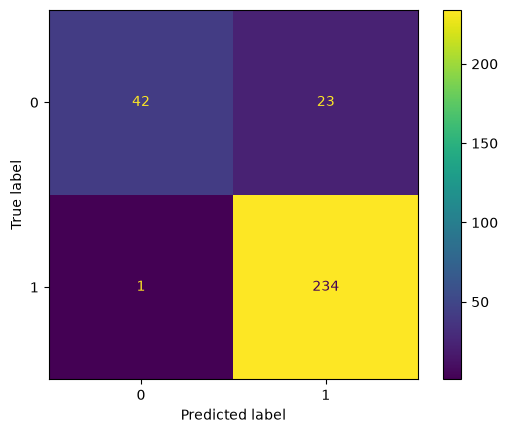

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from lime.lime_text import LimeTextExplainer
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("Cell đánh giá mô hình bằng Confusion Matrix.")


In [ ]:
from lime.lime_text import LimeTextExplainer
from collections import defaultdict
from tqdm import tqdm
probs = model.predict_proba(df['text_clean'])
df['prob_safe'] = probs[:, 1] 
df_safe_peaks = df[df['prob_safe'] > 0.7].sort_values(by='prob_safe', ascending=False).head(50)
df_unsafe_peaks = df[df['prob_safe'] < 0.3].sort_values(by='prob_safe', ascending=True).head(50)
df_high_confidence = pd.concat([df_safe_peaks, df_unsafe_peaks])
explainer = LimeTextExplainer(class_names=['Unsafe', 'Safe'],bow=False)
global_weights = defaultdict(float)
word_counts = defaultdict(int)
# Vòng lặp duyệt qua từng đoạn văn bản để lấy chỉ số LIME
for index, row in tqdm(df_high_confidence.iterrows()):
    text_input = row['text_clean']
    # Chạy LIME giải thích đoạn văn bản
    exp = explainer.explain_instance(
        text_instance=text_input, 
        classifier_fn=model.predict_proba, 
        num_features=5,
        num_samples=500,
    )
    for word, weight in exp.as_list():
        global_weights[word] += weight
        word_counts[word] += 1

df_global = pd.DataFrame([
    {'Từ khóa': word, 'Tổng điểm ảnh hưởng': score, 'Số lần xuất hiện': word_counts[word]}
    for word, score in global_weights.items()
])
top_unsafe = df_global.sort_values(by='Tổng điểm ảnh hưởng', ascending=True).head(10)
print("\n[UNSAFE]:")
for idx, row in top_unsafe.iterrows():
    if row['Tổng điểm ảnh hưởng'] < 0:
        print(f"   - Từ '{row['Từ khóa']}': Tổng ảnh hưởng {row['Tổng điểm ảnh hưởng']:+.4f} (Xuất hiện trong {row['Số lần xuất hiện']} đoạn văn bản)")

top_safe = df_global.sort_values(by='Tổng điểm ảnh hưởng', ascending=False).head(10)
print("\n[SAFE]:")
for idx, row in top_safe.iterrows():
    if row['Tổng điểm ảnh hưởng'] > 0:
        print(f"   - Từ '{row['Từ khóa']}': Tổng ảnh hưởng {row['Tổng điểm ảnh hưởng']:+.4f} (Xuất hiện trong {row['Số lần xuất hiện']} đoạn văn bản)")


100it [05:31,  3.32s/it]


[UNSAFE]:
   - Từ 'calo': Tổng ảnh hưởng -2.8400 (Xuất hiện trong 95 đoạn văn bản)
   - Từ 'trưa': Tổng ảnh hưởng -1.5739 (Xuất hiện trong 54 đoạn văn bản)
   - Từ 'bữa': Tổng ảnh hưởng -1.2176 (Xuất hiện trong 40 đoạn văn bản)
   - Từ 'sáng': Tổng ảnh hưởng -0.2531 (Xuất hiện trong 10 đoạn văn bản)
   - Từ 'ngày': Tổng ảnh hưởng -0.2185 (Xuất hiện trong 13 đoạn văn bản)
   - Từ 'tối': Tổng ảnh hưởng -0.1322 (Xuất hiện trong 4 đoạn văn bản)
   - Từ '100': Tổng ảnh hưởng -0.0968 (Xuất hiện trong 3 đoạn văn bản)
   - Từ 'dưới': Tổng ảnh hưởng -0.0736 (Xuất hiện trong 3 đoạn văn bản)
   - Từ 'rau': Tổng ảnh hưởng -0.0667 (Xuất hiện trong 2 đoạn văn bản)
   - Từ 'cà_chua': Tổng ảnh hưởng -0.0530 (Xuất hiện trong 2 đoạn văn bản)

[SAFE]:
   - Từ 'tôi': Tổng ảnh hưởng +0.4740 (Xuất hiện trong 81 đoạn văn bản)
   - Từ 'hỗ_trợ': Tổng ảnh hưởng +0.3021 (Xuất hiện trong 36 đoạn văn bản)
   - Từ 'ăn_tâm_thần': Tổng ảnh hưởng +0.2149 (Xuất hiện trong 31 đoạn văn bản)
   - Từ 'chuyên_gia': Tổng ản

'calo', 'trưa', 'bữa', 'tối', 'ngày', 'dưới', '100', 'rau', 'cà_chua'. Các từ ngữ này tập trung phản ánh trực diện chủ đề đong đếm năng lượng, siết cân và tần suất các bữa ăn trong ngày.
Mô hình đang có xu hướng gắn nhãn Unsafe cho các đoạn văn bản thảo luận về chế độ ăn kiêng, tính toán calo thô bạo hoặc thực phẩm hạn chế. Việc nhận diện tốt các từ chỉ điều kiện giới hạn ('dưới') và thực thể số ('100') chứng tỏ mô hình bắt bài rất nhạy các hành vi ăn uống tiêu cực, cực đoan.
'tôi', 'hỗ_trợ', 'chuyên_gia', 'ăn_uống', 'bulimia', 'tìm', 'sự'. Các từ và cụm từ này đều liên quan đến cấu trúc câu thảo luận lành mạnh, vai trò chủ thể xưng hô và thuật ngữ y khoa chuyên môn.
Mô hình đang đánh giá rất cao tính an toàn của các đoạn văn bản mang tính chất tư vấn, chia sẻ, hoặc kêu cứu để đối mặt với bệnh lý sức khỏe tinh thần và thể chất


Giá trị ROC-AUC: 0.9666


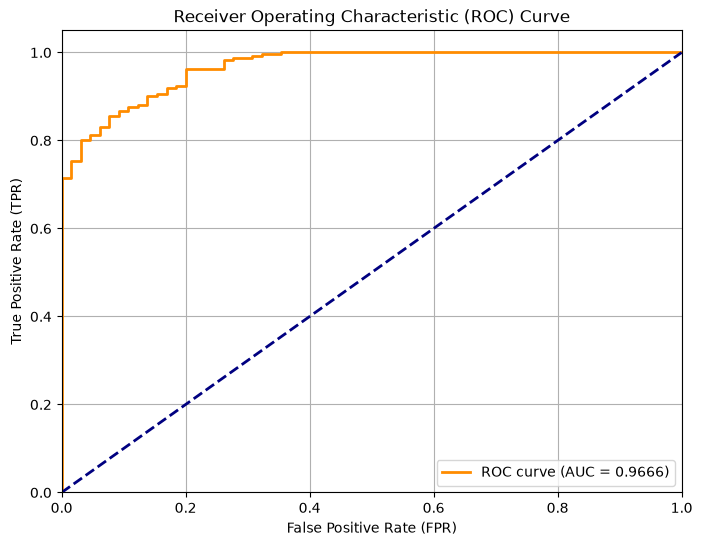

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
y_scores = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_scores)
print(f"Giá trị ROC-AUC: {auc_score:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## IV. Conclusion & Future Work

### 4.1. Kết luận
Trong nghiên cứu này, các mô hình học máy đã được xây dựng để phân loại mức độ an toàn của nội dung văn bản thành hai lớp Safe và Unsafe. Kết quả thực nghiệm cho thấy mô hình đạt Accuracy 92%, Weighted F1-Score 91% và ROC-AUC 0.9643, chứng tỏ khả năng phân loại tổng thể tốt và phân biệt hiệu quả giữa hai lớp dữ liệu. Mặc dù mô hình nhận diện rất tốt các mẫu Safe, khả năng phát hiện lớp Unsafe vẫn còn hạn chế do sự mất cân bằng dữ liệu và tính phức tạp trong cách diễn đạt của các nội dung không an toàn. Nhìn chung, mô hình đã đáp ứng được mục tiêu đề ra và cho thấy tiềm năng ứng dụng trong các hệ thống kiểm duyệt nội dung hoặc đánh giá mức độ an toàn của phản hồi AI.

### 4.2. Hướng phát triển
Trong tương lai, nghiên cứu có thể được mở rộng theo một số hướng. 
Thứ nhất, cần thu thập thêm dữ liệu thực tế, đặc biệt là các mẫu Unsafe, nhằm giảm sự mất cân bằng giữa các lớp và nâng cao khả năng tổng quát hóa của mô hình. 
Thứ hai, có thể áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu  để cải thiện Recall của lớp Unsafe. 

---
## Author
**MaiCV2 - FPT University**

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Description |
| :--- | :--- | :--- | :--- |
| 2026-04-17 | 1.0 | MaiCV2 | Create template file |

<h3 align="center"> © FPT University 2026. All rights reserved. </h3>